In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("dataset.xlsx")
df.head()

,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
0,4_Eur,ESP,Spain,A Coruna/ESP,2013.0,"V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...",23.238,11.491,28.841,87.0,46.0,93.0,"Urban, Urban, Suburban",NaN,NaN,246146.0,"manual, manual, manual, manual",43.367900,-8.418571,1
1,4_Eur,ESP,Spain,A Coruna/ESP,2014.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023)",27.476,15.878,19.575,96.0,88.0,95.0,"Urban, Urban, Suburban",NaN,NaN,247604.0,NaN,43.368033,-8.418233,1
2,4_Eur,ESP,Spain,A Coruna/ESP,2015.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",25.515,14.004,22.731,98.0,71.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
3,4_Eur,ESP,Spain,A Coruna/ESP,2016.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",23.057,13.160,20.204,98.0,98.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
4,4_Eur,ESP,Spain,A Coruna/ESP,2017.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",26.849,14.114,21.543,97.0,97.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40098 entries, 0 to 40097
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   who_region          40098 non-null  object 
 1   iso3                40098 non-null  object 
 2   country_name        40098 non-null  object 
 3   city                40098 non-null  object 
 4   year                40095 non-null  float64
 5   version             40098 non-null  object 
 6   pm10_concentration  28672 non-null  float64
 7   pm25_concentration  21730 non-null  float64
 8   no2_concentration   26934 non-null  float64
 9   pm10_tempcov        22403 non-null  float64
 10  pm25_tempcov        16590 non-null  float64
 11  no2_tempcov         23402 non-null  float64
 12  type_of_stations    23331 non-null  object 
 13  reference           6652 non-null   object 
 14  web_link            1790 non-null   object 
 15  population          22433 non-null  float64
 16  popu

In [4]:
df.isnull().sum()

who_region                0
iso3                      0
country_name              0
city                      0
year                      3
version                   0
pm10_concentration    11426
pm25_concentration    18368
no2_concentration     13164
pm10_tempcov          17695
pm25_tempcov          23508
no2_tempcov           16696
type_of_stations      16767
reference             33446
web_link              38308
population            17665
population_source     21996
latitude                  0
longitude                 0
who_ms                    0
dtype: int64

In [5]:
df.describe()

,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,population,latitude,longitude,who_ms
count,40095.000000,28672.000000,21730.000000,26934.000000,22403.000000,16590.000000,23402.000000,2.243300e+04,40098.000000,40098.000000,40098.000000
mean,2016.232672,30.016375,19.130923,18.861620,88.732134,84.124533,88.092214,7.571931e+05,40.024341,10.598472,0.998803
std,3.116678,29.548575,17.490027,25.845061,20.277271,26.819096,23.149637,2.123730e+06,16.309381,57.774989,0.034578
min,2010.000000,0.730000,1.000000,0.002000,0.000000,0.000000,0.000000,5.000000e+00,-53.158316,-159.366240,0.000000
25%,2014.000000,16.264750,8.603250,10.163250,90.000000,86.000000,92.000000,5.300600e+04,37.138800,-1.258900,1.000000
50%,2016.000000,21.335500,12.710500,16.700000,96.000000,96.000000,96.000000,1.637290e+05,43.822900,10.512933,1.000000
75%,2019.000000,30.515500,23.000000,24.911500,99.000000,99.000000,98.000000,5.900320e+05,49.163367,23.226400,1.000000
max,2022.000000,540.000000,436.440000,3670.314000,100.000000,100.000000,100.000000,3.739313e+07,69.677498,178.450000,1.000000


In [6]:
df.columns

Index(['who_region', 'iso3', 'country_name', 'city', 'year', 'version',
       'pm10_concentration', 'pm25_concentration', 'no2_concentration',
       'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'type_of_stations',
       'reference', 'web_link', 'population', 'population_source', 'latitude',
       'longitude', 'who_ms'],
      dtype='object')

In [7]:
columns_to_drop = ['version','type_of_stations','reference','web_link','population_source','who_ms'] 
df = df.drop(columns=columns_to_drop, errors='ignore')

In [8]:
df.head()

,who_region,iso3,country_name,city,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,population,latitude,longitude
0,4_Eur,ESP,Spain,A Coruna/ESP,2013.0,23.238,11.491,28.841,87.0,46.0,93.0,246146.0,43.367900,-8.418571
1,4_Eur,ESP,Spain,A Coruna/ESP,2014.0,27.476,15.878,19.575,96.0,88.0,95.0,247604.0,43.368033,-8.418233
2,4_Eur,ESP,Spain,A Coruna/ESP,2015.0,25.515,14.004,22.731,98.0,71.0,98.0,247604.0,43.370375,-8.422900
3,4_Eur,ESP,Spain,A Coruna/ESP,2016.0,23.057,13.160,20.204,98.0,98.0,98.0,247604.0,43.370375,-8.422900
4,4_Eur,ESP,Spain,A Coruna/ESP,2017.0,26.849,14.114,21.543,97.0,97.0,98.0,247604.0,43.370375,-8.422900


In [9]:
df.columns

Index(['who_region', 'iso3', 'country_name', 'city', 'year',
       'pm10_concentration', 'pm25_concentration', 'no2_concentration',
       'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'population', 'latitude',
       'longitude'],
      dtype='object')

In [10]:
df.rename(columns={
    'who_region': 'Region',
    'iso3': 'ISO3 Code',
    'country_name': 'Country',
    'city': 'City',
    'year': 'Year',
    'pm10_concentration': 'PM10',
    'pm25_concentration': 'PM2.5',
    'no2_concentration': 'NO2',
    'pm10_tempcov': 'PM10 Coverage',
    'pm25_tempcov': 'PM2.5 Coverage',
    'no2_tempcov': 'NO2 Coverage',
    'population': 'Population',
    'latitude': 'Latitude',
    'longitude': 'Longitude'
}, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40098 entries, 0 to 40097
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          40098 non-null  object 
 1   ISO3 Code       40098 non-null  object 
 2   Country         40098 non-null  object 
 3   City            40098 non-null  object 
 4   Year            40095 non-null  float64
 5   PM10            28672 non-null  float64
 6   PM2.5           21730 non-null  float64
 7   NO2             26934 non-null  float64
 8   PM10 Coverage   22403 non-null  float64
 9   PM2.5 Coverage  16590 non-null  float64
 10  NO2 Coverage    23402 non-null  float64
 11  Population      22433 non-null  float64
 12  Latitude        40098 non-null  float64
 13  Longitude       40098 non-null  float64
dtypes: float64(10), object(4)
memory usage: 4.3+ MB


In [12]:
# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Convert pollution columns to float
cols_float = [
    'PM10', 'PM2.5', 'NO2',
    'PM10 Coverage', 'PM2.5 Coverage', 'NO2 Coverage',
    'Population', 'Latitude', 'Longitude'
]

for col in cols_float:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical columns
cols_category = ['Region', 'ISO3 Code', 'Country', 'City']

for col in cols_category:
    df[col] = df[col].astype('category')

In [13]:
# Handle Errors (Convert to NaN automatically)
errors='coerce'

In [14]:
# List of all numeric columns with missing values
cols_with_missing = [
    'PM10', 'PM2.5', 'NO2',
    'PM10 Coverage', 'PM2.5 Coverage', 'NO2 Coverage',
    'Population', 'Latitude', 'Longitude', 'Year'
]

# Fill missing values with median
for col in cols_with_missing:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # ensure numeric
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

In [15]:
df.isnull().sum()

Region            0
ISO3 Code         0
Country           0
City              0
Year              0
PM10              0
PM2.5             0
NO2               0
PM10 Coverage     0
PM2.5 Coverage    0
NO2 Coverage      0
Population        0
Latitude          0
Longitude         0
dtype: int64

In [16]:
df.columns

Index(['Region', 'ISO3 Code', 'Country', 'City', 'Year', 'PM10', 'PM2.5',
       'NO2', 'PM10 Coverage', 'PM2.5 Coverage', 'NO2 Coverage', 'Population',
       'Latitude', 'Longitude'],
      dtype='object')

In [17]:
df['Region'].unique()

['4_Eur', '6_Wpr', '2_Amr', '5_Emr', '1_Afr', '3_Sear', '7_NonMS']
Categories (7, object): ['1_Afr', '2_Amr', '3_Sear', '4_Eur', '5_Emr', '6_Wpr', '7_NonMS']

In [18]:
region_mapping = {
    '1_Afr': 'Africa',
    '2_Amr': 'Americas',
    '3_Sear': 'South-East Asia',
    '4_Eur': 'Europe',
    '5_Emr': 'Eastern Mediterranean',
    '6_Wpr': 'Western Pacific',
    '7_NonMS': 'Non-Member States'
}

df['Region'] = df['Region'].replace(region_mapping)

C:\Users\tanis\AppData\Local\Temp\ipykernel_15044\2541459520.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Region'] = df['Region'].replace(region_mapping)


In [19]:
# Round Values
cols_to_round = [
    'PM2.5', 'PM10', 'NO2',
    'PM10 Coverage', 'PM2.5 Coverage', 'NO2 Coverage',
    'Population', 'Latitude', 'Longitude', 'Year'
]

df[cols_to_round] = df[cols_to_round].round(2)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40098 entries, 0 to 40097
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Region          40098 non-null  category
 1   ISO3 Code       40098 non-null  category
 2   Country         40098 non-null  category
 3   City            40098 non-null  category
 4   Year            40098 non-null  Int64   
 5   PM10            40098 non-null  float64 
 6   PM2.5           40098 non-null  float64 
 7   NO2             40098 non-null  float64 
 8   PM10 Coverage   40098 non-null  float64 
 9   PM2.5 Coverage  40098 non-null  float64 
 10  NO2 Coverage    40098 non-null  float64 
 11  Population      40098 non-null  float64 
 12  Latitude        40098 non-null  float64 
 13  Longitude       40098 non-null  float64 
dtypes: Int64(1), category(4), float64(9)
memory usage: 3.6 MB


In [21]:
df.describe()

,Year,PM10,PM2.5,NO2,PM10 Coverage,PM2.5 Coverage,NO2 Coverage,Population,Latitude,Longitude
count,40098.0,40098.000000,40098.000000,40098.000000,40098.000000,40098.000000,40098.000000,4.009800e+04,40098.000000,40098.000000
mean,2016.232655,27.544039,16.189624,18.151975,91.939398,91.086688,91.384857,4.957451e+05,40.024306,10.598475
std,3.116562,25.291379,13.266694,21.206142,15.580153,18.214917,18.109560,1.615557e+06,16.309321,57.774977
min,2010.0,0.730000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,-53.160000,-159.370000
25%,2014.0,18.220000,11.920000,13.390000,96.000000,96.000000,95.000000,1.268660e+05,37.140000,-1.260000
50%,2016.0,21.340000,12.710000,16.700000,96.000000,96.000000,96.000000,1.637290e+05,43.820000,10.510000
75%,2019.0,25.610000,13.600000,20.520000,97.000000,96.000000,96.000000,2.146310e+05,49.160000,23.230000
max,2022.0,540.000000,436.440000,3670.310000,100.000000,100.000000,100.000000,3.739313e+07,69.680000,178.450000


In [22]:
# 🔷 Additional Statistical Analysis
print("Median Values:\n")
print(df[['PM2.5','PM10','NO2']].median())

print("\nStandard Deviation:\n")
print(df[['PM2.5','PM10','NO2']].std())

print("\nVariance:\n")
print(df[['PM2.5','PM10','NO2']].var())

Median Values:

PM2.5    12.71
PM10     21.34
NO2      16.70
dtype: float64

Standard Deviation:

PM2.5    13.266694
PM10     25.291379
NO2      21.206142
dtype: float64

Variance:

PM2.5    176.005172
PM10     639.653864
NO2      449.700459
dtype: float64


In [23]:
print("\nRegion-wise Average Pollution:\n")
print(df.groupby('Region')[['PM2.5','PM10','NO2']].mean().sort_values(by='PM2.5', ascending=False))

print("\nPollutant Summary:\n")
print(df[['PM2.5', 'PM10', 'NO2']].describe())

print("\nYear-wise Average Pollution:\n")
print(df.groupby('Year')[['PM2.5','PM10','NO2']].mean())

print("\nCorrelation Matrix:\n")
print(df[['PM2.5','PM10','NO2']].corr())

print("\nQuartiles:\n")
print(df[['PM2.5','PM10','NO2']].quantile([0.25,0.5,0.75]))




Region-wise Average Pollution:

                           PM2.5        PM10        NO2
Region                                                 
Western Pacific        38.210902   29.833398  17.686118
Eastern Mediterranean  24.911197  103.510540  29.456808
South-East Asia        23.695466   93.417792  18.412177
Africa                 23.666453   48.081921  21.148867
Europe                 13.100370   22.550720  18.545462
Non-Member States      12.888125   35.592917  14.591875
Americas               10.233158   24.418630  15.932031

Pollutant Summary:

              PM2.5          PM10           NO2
count  40098.000000  40098.000000  40098.000000
mean      16.189624     27.544039     18.151975
std       13.266694     25.291379     21.206142
min        1.000000      0.730000      0.000000
25%       11.920000     18.220000     13.390000
50%       12.710000     21.340000     16.700000
75%       13.600000     25.610000     20.520000
max      436.440000    540.000000   3670.310000

Year-wise

C:\Users\tanis\AppData\Local\Temp\ipykernel_15044\3794073467.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Region')[['PM2.5','PM10','NO2']].mean().sort_values(by='PM2.5', ascending=False))


In [24]:
df.head()

,Region,ISO3 Code,Country,City,Year,PM10,PM2.5,NO2,PM10 Coverage,PM2.5 Coverage,NO2 Coverage,Population,Latitude,Longitude
0,Europe,ESP,Spain,A Coruna/ESP,2013,23.24,11.49,28.84,87.0,46.0,93.0,246146.0,43.37,-8.42
1,Europe,ESP,Spain,A Coruna/ESP,2014,27.48,15.88,19.58,96.0,88.0,95.0,247604.0,43.37,-8.42
2,Europe,ESP,Spain,A Coruna/ESP,2015,25.52,14.00,22.73,98.0,71.0,98.0,247604.0,43.37,-8.42
3,Europe,ESP,Spain,A Coruna/ESP,2016,23.06,13.16,20.20,98.0,98.0,98.0,247604.0,43.37,-8.42
4,Europe,ESP,Spain,A Coruna/ESP,2017,26.85,14.11,21.54,97.0,97.0,98.0,247604.0,43.37,-8.42


C:\Users\tanis\AppData\Local\Temp\ipykernel_15044\1366491322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_avg = df.groupby('Region')[['PM2.5', 'PM10', 'NO2']].mean().reset_index()


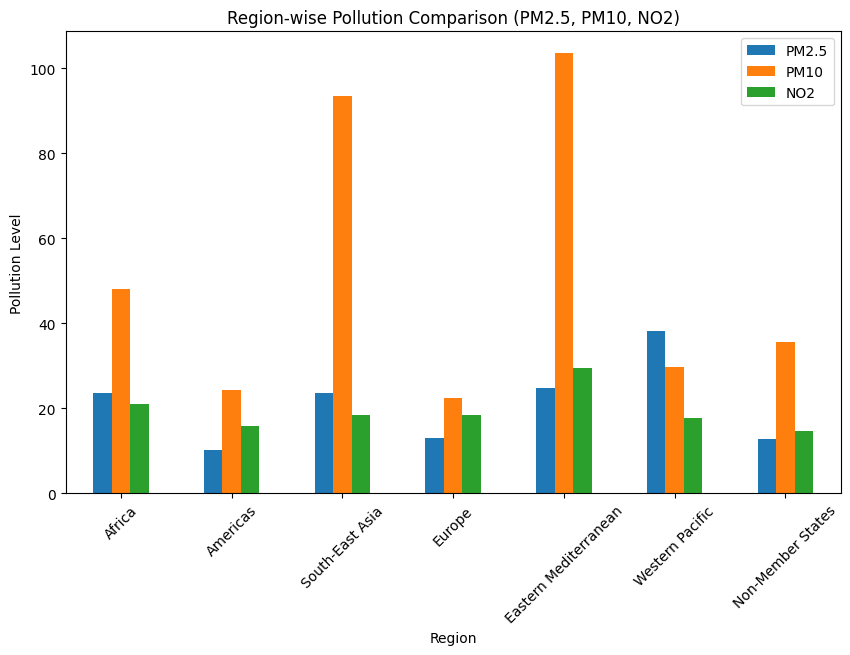

In [25]:
region_avg = df.groupby('Region')[['PM2.5', 'PM10', 'NO2']].mean().reset_index()

region_avg.plot(x='Region', kind='bar', figsize=(10,6))
plt.title("Region-wise Pollution Comparison (PM2.5, PM10, NO2)")
plt.xticks(rotation=45)
plt.ylabel("Pollution Level")
plt.show()

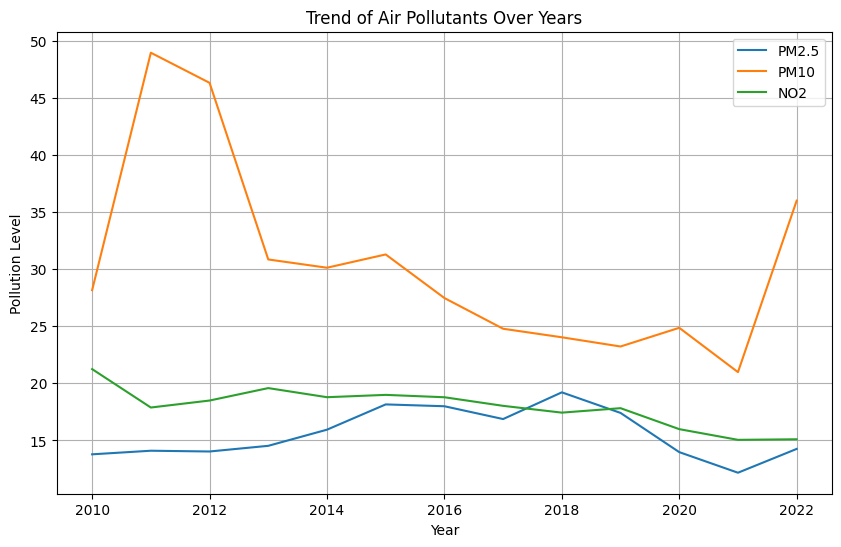

In [26]:
yearly_avg = df.groupby('Year')[['PM2.5', 'PM10', 'NO2']].mean()

yearly_avg.plot(figsize=(10,6))
plt.title("Trend of Air Pollutants Over Years")
plt.ylabel("Pollution Level")
plt.grid(True)
plt.show()

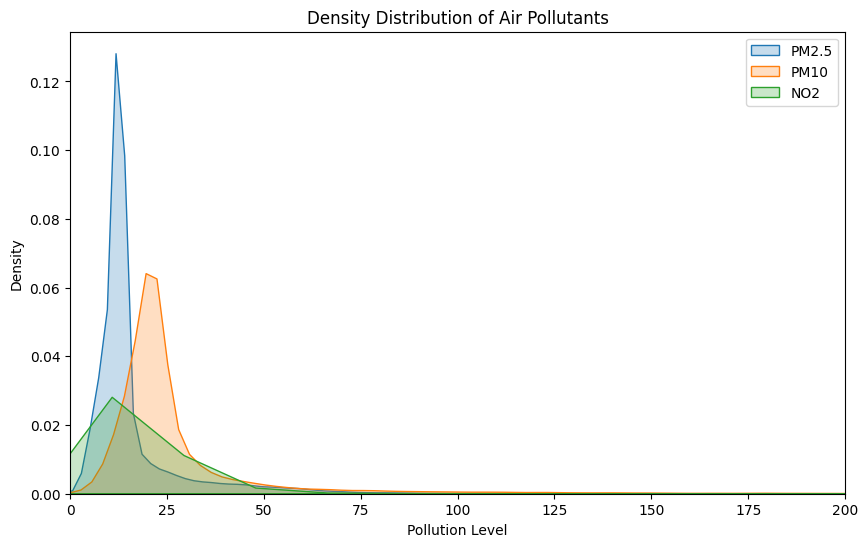

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.kdeplot(df['PM2.5'], label='PM2.5', fill=True)
sns.kdeplot(df['PM10'], label='PM10', fill=True)
sns.kdeplot(df['NO2'], label='NO2', fill=True)

plt.xlim(0, 200)   # zoom

plt.title("Density Distribution of Air Pollutants")
plt.xlabel("Pollution Level")
plt.ylabel("Density")

plt.legend()
plt.show()

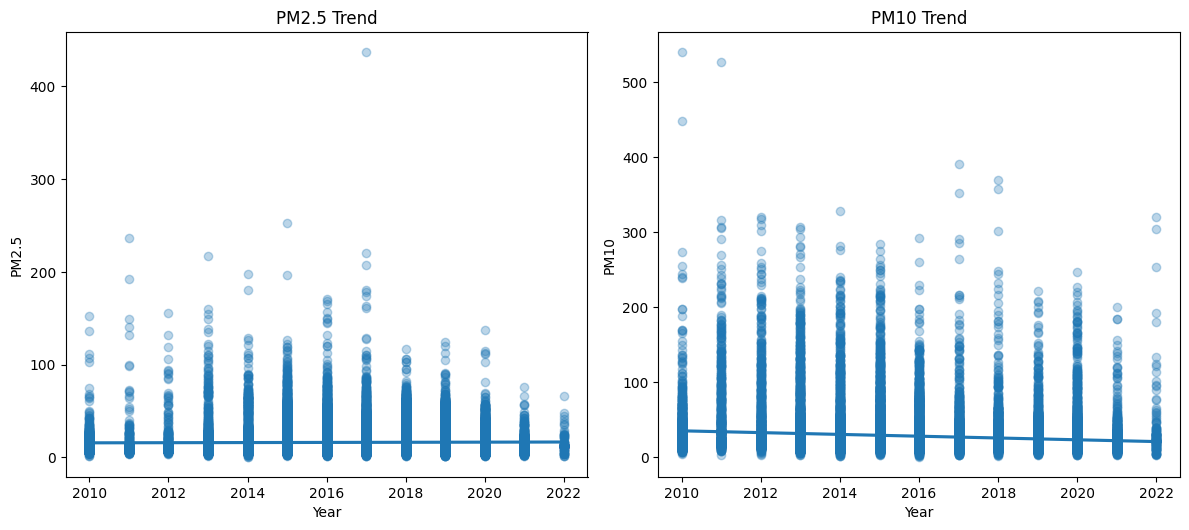

In [28]:
# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Flatten axes
axes = axes.flatten()

# PM2.5
sns.regplot(
    x='Year', y='PM2.5', data=df,
    scatter_kws={'alpha':0.3},
    ax=axes[0]
)
axes[0].set_title("PM2.5 Trend")

# PM10
sns.regplot(
    x='Year', y='PM10', data=df,
    scatter_kws={'alpha':0.3},
    ax=axes[1]
)
axes[1].set_title("PM10 Trend")

# Remove unused plots
fig.delaxes(axes[2])
fig.delaxes(axes[3])

# Adjust layout
plt.tight_layout()

plt.show()

C:\Users\tanis\AppData\Local\Temp\ipykernel_15044\3938992408.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_pollution = df.groupby('Country')[['PM2.5', 'PM10', 'NO2']].mean()


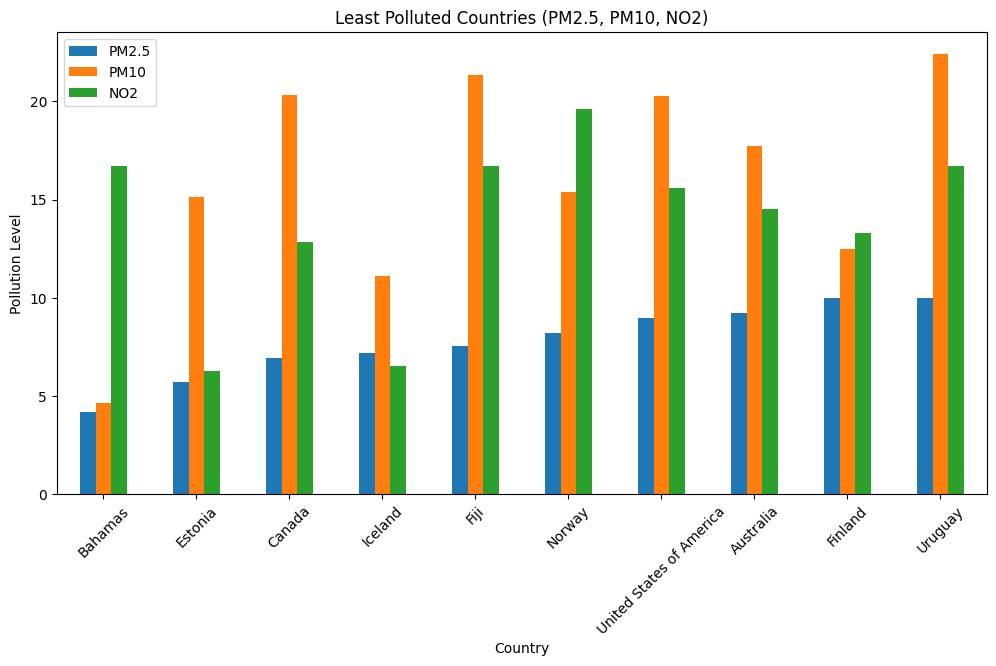

In [29]:
country_pollution = df.groupby('Country')[['PM2.5', 'PM10', 'NO2']].mean()

least_polluted = country_pollution.sort_values(by='PM2.5').head(10)

least_polluted.plot(kind='bar', figsize=(12,6))
plt.title("Least Polluted Countries (PM2.5, PM10, NO2)")
plt.ylabel("Pollution Level")
plt.xticks(rotation=45)
plt.show()

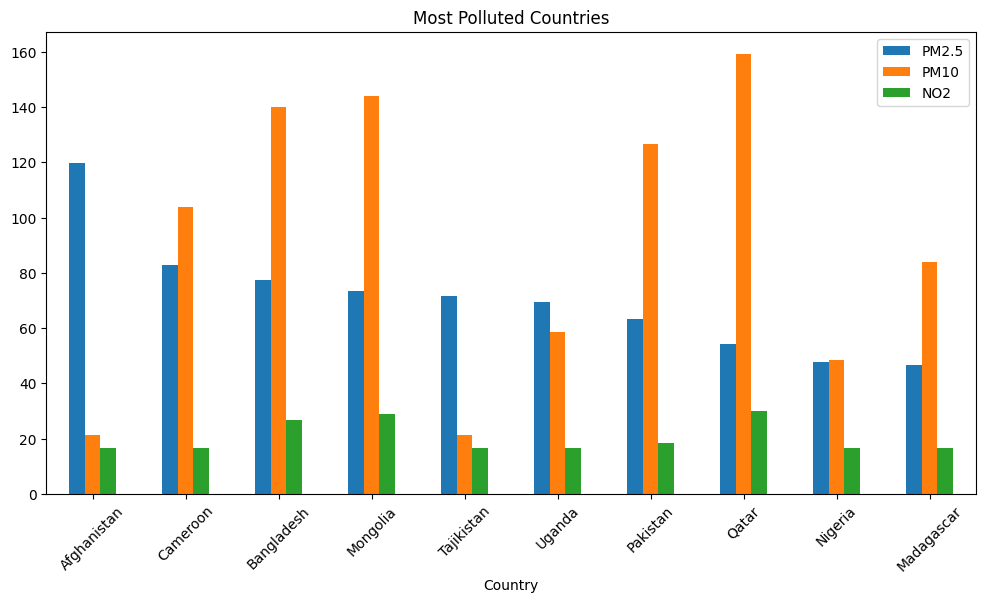

In [30]:
most_polluted = country_pollution.sort_values(by='PM2.5', ascending=False).head(10)

most_polluted.plot(kind='bar', figsize=(12,6))
plt.title("Most Polluted Countries")
plt.xticks(rotation=45)
plt.show()

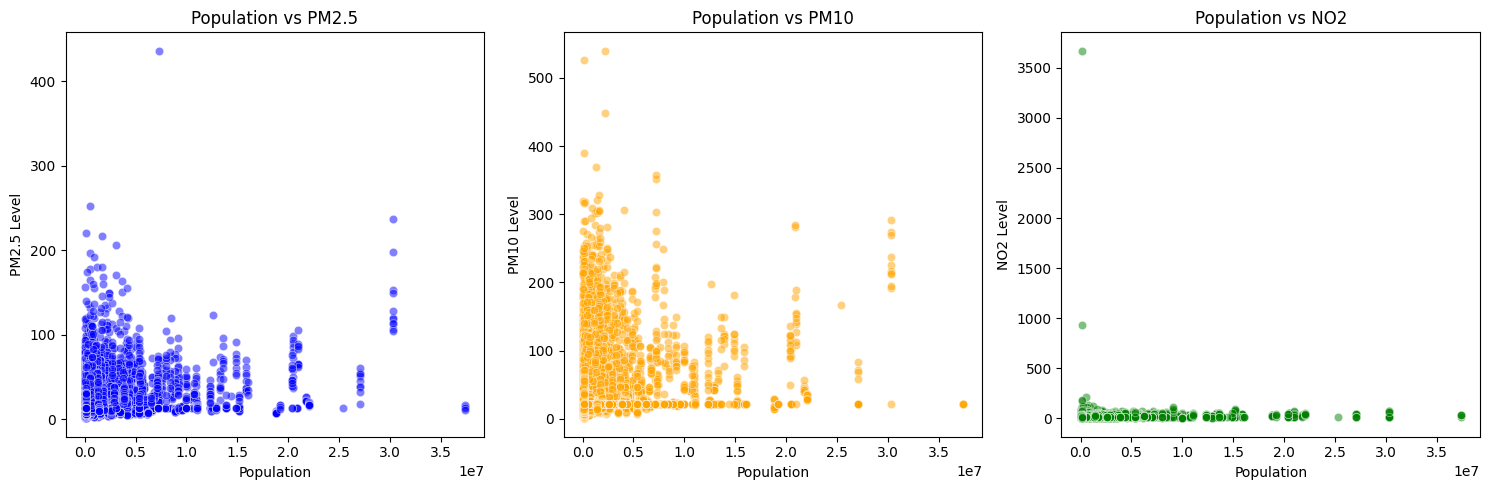

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

pollutants = ['PM2.5', 'PM10', 'NO2']
colors = ['blue', 'orange', 'green'] 

for i, col in enumerate(pollutants):
    
    sns.scatterplot(
        x='Population',
        y=col,
        data=df,
        alpha=0.5,
        color=colors[i],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Population vs {col}")
    axes[i].set_xlabel("Population")
    axes[i].set_ylabel(f"{col} Level")

plt.tight_layout()
plt.show()

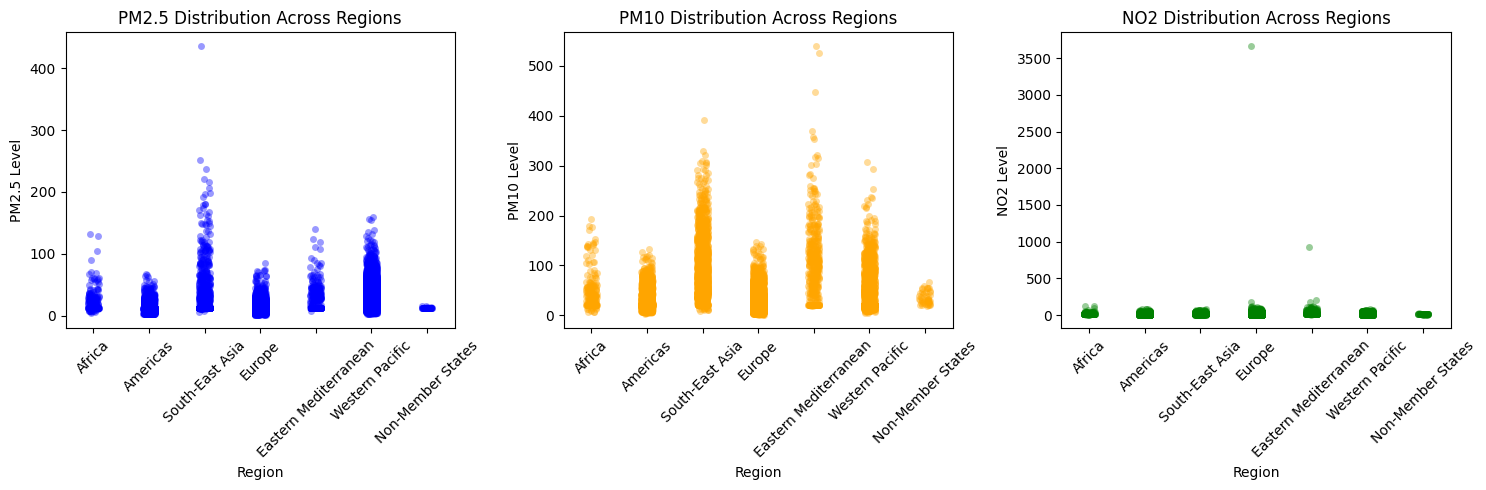

In [32]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15,5))

pollutants = ['PM2.5', 'PM10', 'NO2']
colors = ['blue', 'orange', 'green'] 

for i, col in enumerate(pollutants):
    
    sns.stripplot(
        x='Region',
        y=col,
        data=df,
        jitter=True,
        alpha=0.4,
        color=colors[i],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Distribution Across Regions")
    axes[i].set_xlabel("Region")
    axes[i].set_ylabel(f"{col} Level")
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()

plt.show()

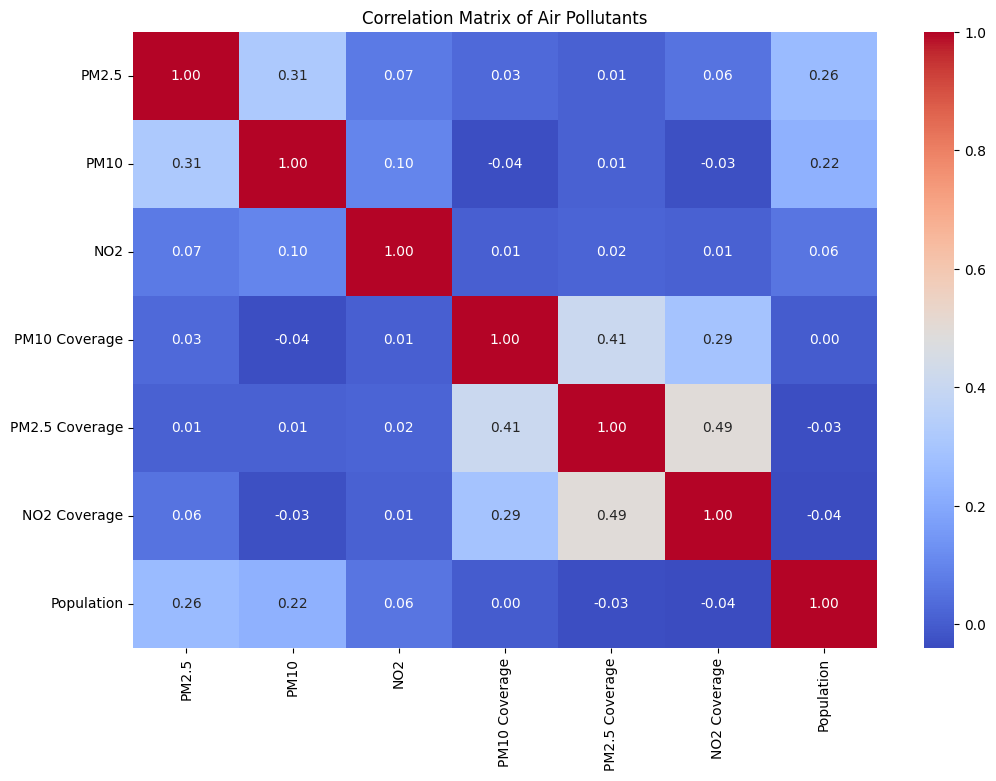

In [33]:
plt.figure(figsize=(12,8))

# Select only relevant numeric columns
corr_data = df[['PM2.5', 'PM10', 'NO2',
                'PM10 Coverage', 'PM2.5 Coverage', 'NO2 Coverage',
                'Population']].corr()

sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Air Pollutants")
plt.show()

In [34]:
def category(pm):
    if pm < 12:
        return "Good"
    elif pm < 35:
        return "Moderate"
    elif pm < 55:
        return "Unhealthy for Sensitive"
    else:
        return "Unhealthy"
df['Category'] = df['PM2.5'].apply(category)

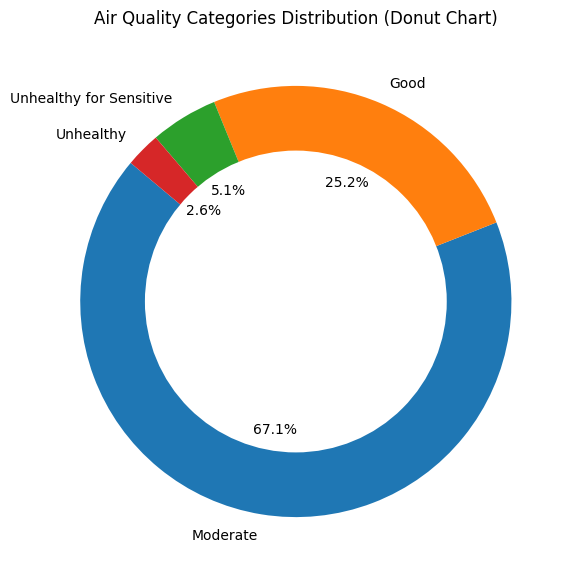

In [35]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(7,7))

# Create pie chart
wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

# Add center circle (donut effect)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Air Quality Categories Distribution (Donut Chart)")

plt.show()